In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
import keras
keras.utils.set_random_seed(SEED)

# 데이터 불러오기

In [2]:
!gdown https://drive.google.com/uc?id=1-MgHBM01grW2O8N-aVO5p5en16Ko-aH5

Downloading...
From (original): https://drive.google.com/uc?id=1-MgHBM01grW2O8N-aVO5p5en16Ko-aH5
From (redirected): https://drive.google.com/uc?id=1-MgHBM01grW2O8N-aVO5p5en16Ko-aH5&confirm=t&uuid=4d0275e0-9c6c-473c-95e7-c758180a42ba
To: /content/PlantVillage.zip
100% 345M/345M [00:04<00:00, 71.6MB/s]


In [ ]:
!unzip PlantVillage.zip

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Potato 분류

In [25]:
CLASS_NAME = ["Potato___Early_blight", "Potato___Late_blight", "Potato___healthy"]

In [26]:
import os
from keras.utils import load_img, img_to_array

def _load_split(split_dir, image_size=(32, 32)):
    images, labels = [], []
    for label, class_name in enumerate(CLASS_NAME):
        class_dir = os.path.join(split_dir, class_name)
        print(class_dir)
        for fname in sorted(os.listdir(class_dir)):
            fpath = os.path.join(class_dir, fname)
            img = load_img(fpath, target_size=image_size)   # PIL 이미지
            images.append(img_to_array(img, dtype="uint8")) # (32,32,3)
            labels.append(label)

    X = np.stack(images, axis=0)                            # (N,32,32,3)
    y = np.array(labels, dtype="uint8").reshape(-1, 1)      # (N,1)
    return X, y


def load_data(base_dir=None, image_size=(32, 32)):
    if base_dir is None:
        base_dir = "/content/PlantVillage"

    x_train, y_train = _load_split(base_dir, image_size)
    x_test,  y_test  = _load_split(base_dir,  image_size)
    return (x_train, y_train), (x_test, y_test)

In [27]:
(x_train, y_train), (x_test, y_test) = load_data()

/content/PlantVillage/Potato___Early_blight
/content/PlantVillage/Potato___Late_blight
/content/PlantVillage/Potato___healthy
/content/PlantVillage/Potato___Early_blight
/content/PlantVillage/Potato___Late_blight
/content/PlantVillage/Potato___healthy


In [28]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((2152, 32, 32, 3), (2152, 1), (2152, 32, 32, 3), (2152, 1))

## 이미지 확인

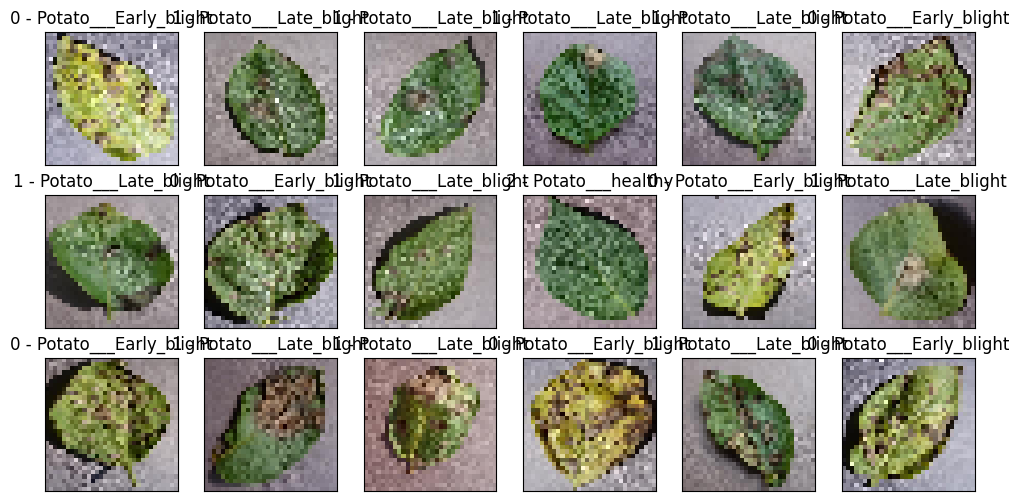

In [29]:
samples = np.random.randint(len(x_train), size=18)

plt.figure(figsize = (12, 6))
for i, idx in enumerate(samples):
    plt.subplot(3, 6, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[idx], cmap = 'gray')
    plt.title(f'{y_train[idx].item()} - {CLASS_NAME[y_train[idx].item()]}')
plt.show()

# 데이터 분리

In [30]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,
                                  test_size = 0.2, random_state = SEED, shuffle=True)
x_train.shape, x_val.shape, y_train.shape, y_val.shape

((1721, 32, 32, 3), (431, 32, 32, 3), (1721, 1), (431, 1))

## 전처리

### Scaling

In [31]:
x_train_s = x_train.astype("float32") / 255.0
x_val_s = x_val.astype("float32") / 255.0

### Encoding - Loss Function에서

# 모델 정의

In [32]:
from keras import layers

def build_basic_model():
  model = keras.Sequential([
   keras.Input(shape=(32, 32, 3)),    # 위에서 데이터셋 크기가 32,32,3 이었음
   layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu'),
   layers.MaxPooling2D(2),
   layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
   layers.MaxPooling2D(2),
   layers.Flatten(),
   layers.Dense(16, activation='relu'),
   layers.Dense(10, activation='softmax')   # output layer
  ])
  return model

In [33]:
model = build_basic_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        18,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,706 (92.60 KB)

 Trainable params: 23,706 (92.60 KB)

 Non-trainable params: 0 (0.00 B)

## Compile

In [34]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['acc']
)

# 학습

In [35]:
EPOCHS = 30

history = model.fit(
    x_train_s, y_train,
    epochs = EPOCHS,
    batch_size = 128,
    validation_data = (x_val_s, y_val)
)

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 301ms/step - acc: 0.4637 - loss: 1.7639 - val_acc: 0.4548 - val_loss: 1.2908
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - acc: 0.4887 - loss: 1.1100 - val_acc: 0.4594 - val_loss: 1.1239
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.5346 - loss: 0.9913 - val_acc: 0.6752 - val_loss: 1.0182
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.6496 - loss: 0.9075 - val_acc: 0.7633 - val_loss: 0.9317
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.7403 - loss: 0.8115 - val_acc: 0.7494 - val_loss: 0.8396
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.8024 - loss: 0.7115 - val_acc: 0.7657 - val_loss: 0.7476
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.8146 - loss: 0.6251 - val_acc: 0.7889 - val_loss: 0.6813
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.8268 - loss: 0.5594 - val_acc: 0.7958 - val_loss: 0.6331
Epoch 9/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8321 - lo

accuracy 95, loss 15

## 결과 그래프

In [36]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure(figsize=(16,8))

  plt.subplot(1,2,1)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
  plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
  plt.legend()

  plt.subplot(1,2,2)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.plot(hist['epoch'], hist['acc'], label='Train Accuracy')
  plt.plot(hist['epoch'], hist['val_acc'], label = 'Val Accuracy')

  plt.legend()
  plt.show()

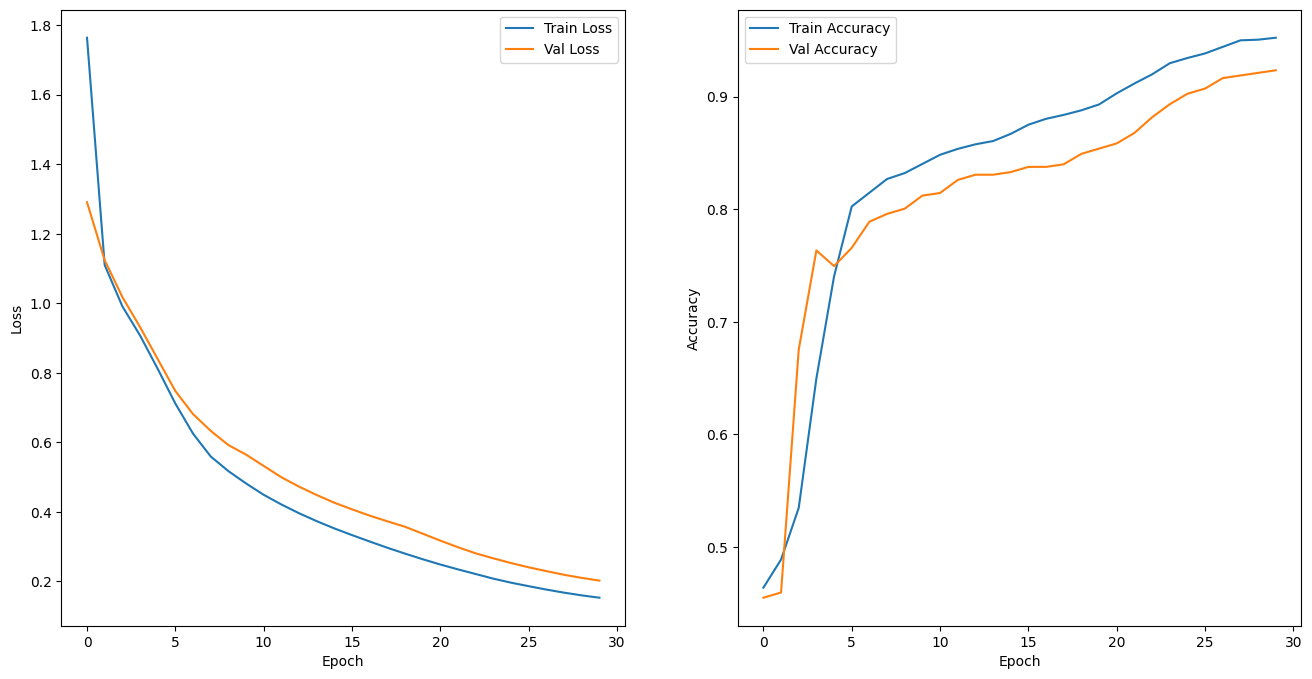

In [37]:
plot_history(history)

# Test

## 전처리

In [38]:
x_test_s = x_test.astype("float32") / 255.0
y_test = np.asarray(y_test).reshape(-1).astype("int32")

## 돌려보기

In [39]:
import tensorflow as tf
loss, accuracy = model.evaluate(x_test_s, tf.constant(y_test, dtype=tf.int32))
loss, accuracy

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc: 0.9419 - loss: 0.1597


(0.15966671705245972, 0.9419144988059998)

loss 16, accuracy 94